# <b>Eighth Stage: $H_2$ Production by Mutant Models</b>

<div style='text-align: justify'>Here, the metabolic implications of HydABC expression in <i>E. coli</i> will be evaluated, including biomass production, NADH production and consumption, and ATP production. Additionally, the effect of NADH production improvement on HydABC activity will be assessed in both models: EC_iCH360_H2_PFOR_25 and EC_iCH360_H2_OGOR_25.</div><br>

<div style='text-align: justify'><b>PS: In further analyses, keep in mind that Acetaldehyde Dehydrogenase (ACALD) here refers specifically to the reverse reaction of the enzyme, namely the conversion of acetyl-CoA to acetaldehyde through the oxidation of one molecule of NADH.</b></div>

In [1]:
# model handling and loading
import cobra
from cobra.io import load_json_model, save_json_model

# data manipulation 
import pandas as pd
import numpy as np

# data visualization
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import plotly.express as px
import seaborn as sns
from PIL import Image
import plotly.io as pio

# Functions constantly used on codes
import functions as f

# Functions for determine OGOR and PPC fluxes
from ipywidgets import interact, interactive
from ipywidgets import FloatSlider, FloatLogSlider

## 8.1 PFOR Model Analysis

### 8.1.1 General Analysis

<div style='text-align: justify'>Let us now visualize how HydABC and PFOR modify <i>E. coli</i> metabolism. Wild type <i>E. coli</i> under anaerobic conditions will be used as the control group to evaluate the main enzymes with altered fluxes. Additionally, the model modified for the expression of PFOR and HydABC, without further modifications, will be referred to as PS0 (an acronym in which PS stands for “PFOR Strain” and the number indicates the simulation).</div>

In [4]:
# control model loading
# model_control = load_json_model('../Models/EC_iCH360.json')

In [3]:
model_control.reactions.get_by_id('EX_o2_e_bw').bounds = (0,0)

solution_control = model_control.optimize()
solution_control

,fluxes,reduced_costs
NDPK5_fw,0.002788,1.235990e-17
SHK3Dr_fw,0.039217,3.469447e-18
NDPK6_fw,0.002700,2.220446e-16
NDPK8_fw,0.002700,0.000000e+00
DHORTS_fw,0.000000,-7.631694e-03
...,...,...
3OAR100_bw,0.000000,-3.431788e-03
3OAR180_bw,0.000000,0.000000e+00
ETOHtrpp_bw,0.000000,0.000000e+00
VPAMTr_bw,0.060182,0.000000e+00


In [3]:
# PFOR and HydABC model
model_anaero_H2_PFOR = load_json_model('../Models/EC_iCH360_H2_PFOR_25.json')

solution_PFOR_H2 = model_anaero_H2_PFOR.optimize()
solution_PFOR_H2

,fluxes,reduced_costs
NDPK5_fw,0.002864,1.810618e-17
SHK3Dr_fw,0.040289,-6.938894e-18
NDPK6_fw,0.002774,0.000000e+00
NDPK8_fw,0.002774,-1.387779e-17
DHORTS_fw,0.000000,-7.838896e-03
...,...,...
HYDFDN_bw,0.000000,-1.220072e-02
EX_h2_e_fw,0.921608,0.000000e+00
H2TPP_fw,0.921608,0.000000e+00
H2tex_fw,0.921608,0.000000e+00


In [4]:
# Total H2 production on PFOR_H2 model (PS0). This will be used on 'General PFOR Consideration' section

h2_0 = sum(model_anaero_H2_PFOR.metabolites.get_by_id('h2_c').summary(solution_PFOR_H2).producing_flux['flux'])
print(f'H2 production: {h2_0:.4f} mmol gDW\u207B\u00B9 h\u207B\u00B9')

H2 production: 0.9216 mmol gDW⁻¹ h⁻¹


In [5]:
# Total H2 production yield (mol H2/mol glucose consumed) on PFOR_H2 model (PS0)
yield_wild_type = h2_0/solution_PFOR_H2.fluxes["EX_glc__D_e_bw"]
print(f'H2 yield: {yield_wild_type} mol H2 / mol glucose')

H2 yield: 0.1002593947425521 mol H2 / mol glucose


### 8.1.4 NADH Synthesis Improvement and $H_2$ Production by HydABC

<div style='text-align: justify'>For analysis of the effects of NADH synthesis on HydABC flux, we will perform two different scenarios, such that total NADH production and its utilization by HydABC will be analyzed:</div>

<ol>
    <li>PPC overexpression;</li>
    <li>CS overexpression;</li>
</ol>

<div style='text-align: justify'>By this, we expect to understand the differences between both enzymes not only in NADH synthesis but also in HydABC utilization of the cofactor.</div><br>

<div style='text-align: justify'><b>From here, for practical purposes, all simulations will be referred to by acronyms, composed of “PS” (referring to “PFOR Strain”) followed by a number. PDH overexpression will be the first simulation and, therefore, will be referred to as PS1. All subsequent analyses will follow this order.</b></div>

### <b>PPC Overexpression</b>

In [6]:
# Calculation of total NADH production, main enzymes involved on NADH consumption and biomass production after HydABC and PFOR expression

# The function will generate a data frame containing Total NADH, Biomass and all enzymes involved on NADH concumption as columns
# Each row indicates a flux of PPC, wich increases as rows increase

PS1 = f.nadh_hyd(model_anaero_H2_PFOR,{"PPC_fw":f.Max(model_anaero_H2_PFOR,"PPC_fw")},0.1)

df_PPC_Hyd = PS1[0]
h2_1 = PS1[1]

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


In [7]:
# For better data visualization, we will remove enzymes that the maximum flux value is lower than 0.1
df_PPC_graph = df_PPC_Hyd.loc[:, (df_PPC_Hyd > 0.1).any(axis=0)]

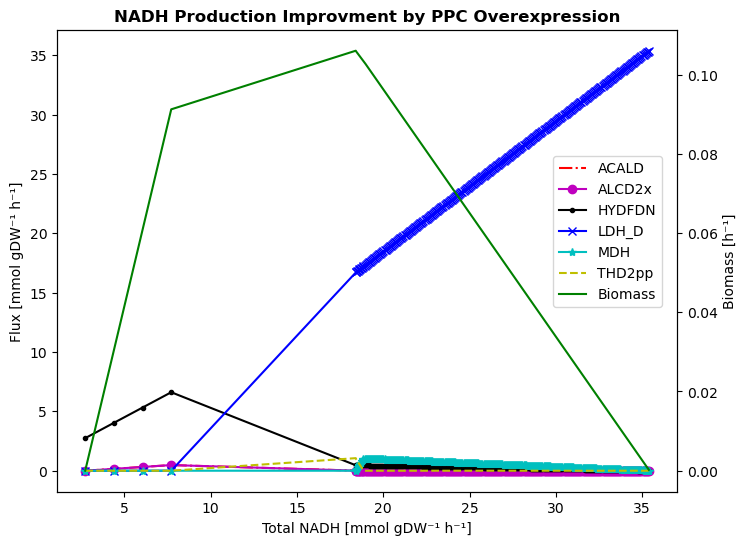

In [8]:
fig, ax = plt.subplots(figsize=(8,6))

color = ['g','r','m','k','b','c','y']
forms = ['-','-.','o-','.-','x-','*-','--']
f.plot_lines(df_PPC_graph,color,forms,'NADH Production Improvment by PPC Overexpression',(0.8,0.4),ax)

fig.savefig('../Images/NADH_PPC.png',dpi=1200)

<div style='text-align: justify'>PS1</div>

In [6]:
# Creation of LDH knockout scenario (PS2)

with model_anaero_H2_PFOR as m_PPC_LDH:
    m_PPC_LDH.reactions.get_by_id('LDH_D_bw').bounds = (0,0)
    upper_PPC_LDH = f.Max(m_PPC_LDH,"PPC_fw")

    PS2 = f.nadh_hyd(m_PPC_LDH,{"PPC_fw":upper_PPC_LDH},0.1)
    
    df_PPC_LDH_KO = PS2[0]

    df_PPC_ko_graph = df_PPC_LDH_KO.copy()
    df_PPC_ko_graph = df_PPC_ko_graph.loc[:, (df_PPC_LDH_KO > 0.1).any(axis=0)]
    df_PPC_ko_graph.loc[:,'Biomass'] = df_PPC_LDH_KO.loc[:,'Biomass']

    h2_2 = PS2[1]

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


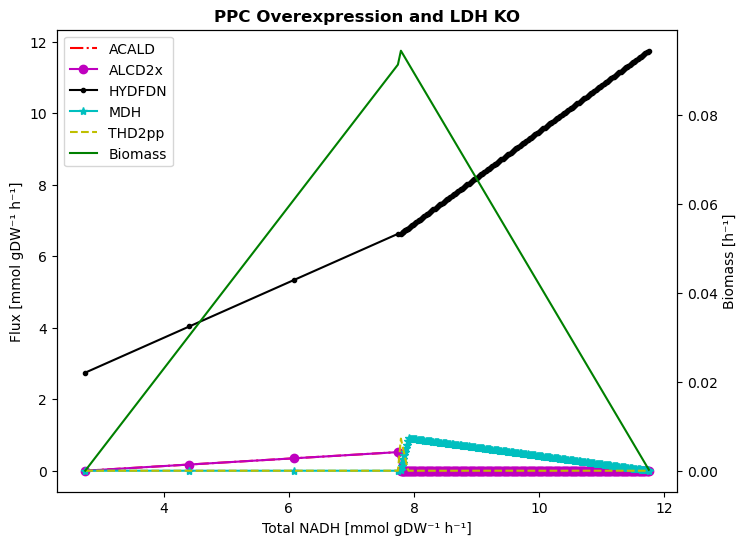

In [10]:
# Generation of the graph

fig, ax = plt.subplots(figsize=(8,6))

f.plot_lines(df_PPC_ko_graph,['r','m','k','c','y','g'],['-.','o-','.-','*-','--','-'],'PPC Overexpression and LDH KO','upper left',ax)

fig.savefig('../Images/NADH_PPC_LDH_KO.png',dpi=1200)

PS2

In [11]:
# Creation of ACALD knockout scenario (PS3)

with model_anaero_H2_PFOR as m_PPC_ACALD:
    m_PPC_ACALD.reactions.get_by_id('ACALD_bw').bounds = (0,0)
    upper_PPC_ACALD = f.Max(m_PPC_ACALD,"PPC_fw")

    PS3 = f.nadh_hyd(m_PPC_ACALD,{"PPC_fw":upper_PPC_ACALD},0.1)
    
    df_PPC_ACALD_KO = PS3[0]
    df_PPC_ACALD_graph = df_PPC_ACALD_KO.loc[:, (df_PPC_ACALD_KO > 0.1).any(axis=0)]


    h2_3 = PS3[1]

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


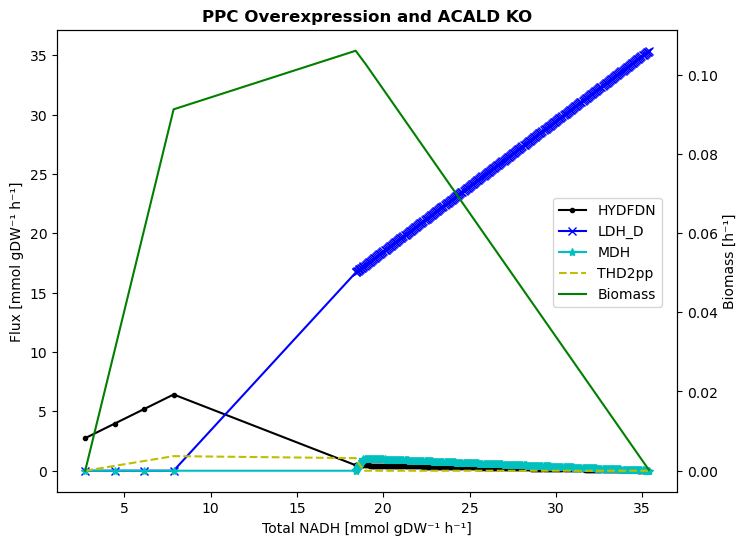

In [12]:
# Generation of the graph

fig, ax = plt.subplots(figsize=(8,6))

# Before plotting, we must sort the data frame by NADH concentration to improve data visualization.
df_PPC_ACALD_graph = df_PPC_ACALD_graph.sort_values(by = 'NADH Total',ascending=True)

f.plot_lines(df_PPC_ACALD_graph,['g','k','b','c','y'],['-','.-','x-','*-','--'],'PPC Overexpression and ACALD KO',(0.8,0.4),ax)

fig.savefig('../Images/NADH_PPC_ACALD_KO.png',dpi=1200)

PS3

In [13]:
# Creation of PFL knockout scenario (PS4)

with model_anaero_H2_PFOR as m_PPC_PFL:
    m_PPC_PFL.reactions.get_by_id('PFL_fw').bounds = (0,0)
    upper_PPC_PFL = f.Max(m_PPC_PFL,"PPC_fw")

    PS4 = f.nadh_hyd(m_PPC_PFL,{"PPC_fw":upper_PPC_PFL},0.1)
    
    df_PPC_PFL_KO = PS4[0]

    df_PPC_PFL_graph = df_PPC_PFL_KO.loc[:, (df_PPC_PFL_KO > 0.1).any(axis=0)]

    h2_4 = PS4[1]

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


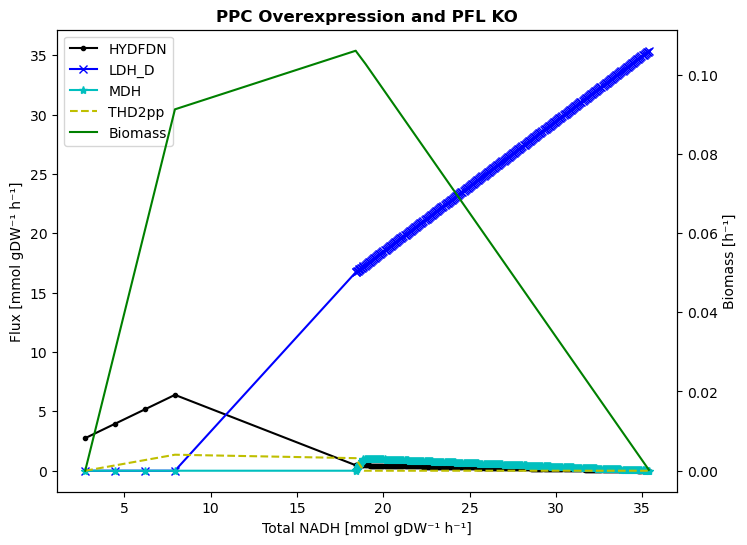

In [14]:
# Generation of the graph

fig, ax = plt.subplots(figsize=(8,6))

# Before plotting, we must sort the data frame by NADH concentration to improve data visualization.
df_PPC_PFL_graph = df_PPC_PFL_graph.sort_values(by = 'NADH Total',ascending=True)

f.plot_lines(df_PPC_PFL_graph,['g','k','b','c','y'],['-','.-','x-','*-','--'],'PPC Overexpression and PFL KO','upper left',ax)

fig.savefig('../Images/NADH_CS_PFL_KO.png',dpi=1200)

PS4

### <b>CS Overexpression</b>

In [15]:
# data frame containing NADH and biomass production, together with the main enzymes responsible for NADH consumption under CS overexpression

PS5 = f.nadh_hyd(model_anaero_H2_PFOR,{"CS_fw":f.Max(model_anaero_H2_PFOR,"CS_fw")},0.1)
df_CS_Hyd = PS5[0]

h2_5 = PS5[1]

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


In [16]:
# For better data visualization, we will remove enzymes that the maximum flux value is lower than 0.1
df_CS_graph = df_CS_Hyd.loc[:, (df_CS_Hyd > 0.1).any(axis=0)]

# Removing unconstant values of FBA
df_const = df_CS_graph.copy()
df_const = df_const.drop(df_const[df_const["HYDFDN_fw"]>7.368509].index)

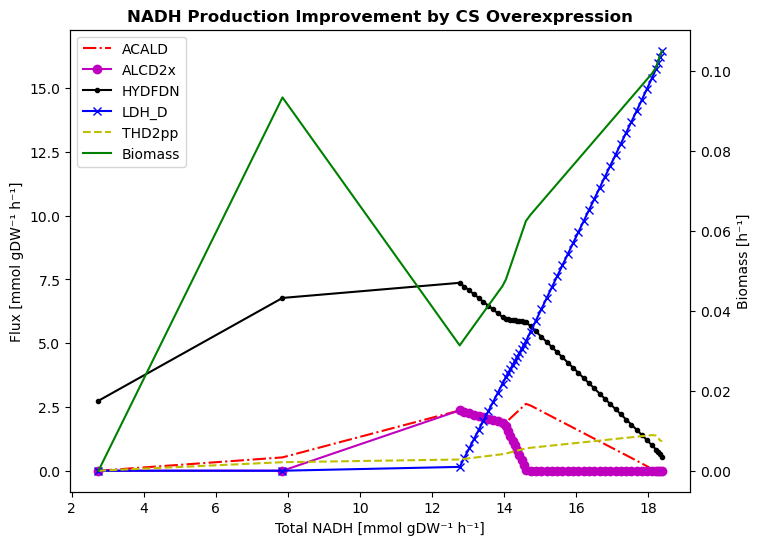

In [17]:
fig, ax = plt.subplots(figsize=(8,6))

# Before plotting, we must sort the data frame by NADH concentration to improve data visualization.
df_const = df_const.sort_values(by = 'NADH Total',ascending=True)

f.plot_lines(df_const,['g','r','m','k','b','y'],['-','-.','o-','.-','x-','--'],'NADH Production Improvement by CS Overexpression','upper left',ax)

fig.savefig('../Images/NADH_CS_PFOR.png',dpi=1200)

<div style='text-align: justify'>PS5</div>

In [18]:
# Creation of LDH knockout scenario (PS6)

with model_anaero_H2_PFOR as m_CS_LDH:
    m_CS_LDH.reactions.get_by_id('LDH_D_bw').bounds = (0,0)
    upper_CS_LDH = f.Max(m_CS_LDH,"CS_fw")

    PS6 = f.nadh_hyd(m_CS_LDH,{"CS_fw":upper_CS_LDH},0.1)
    
    df_CS_LDH_KO = PS6[0]

    df_CS_ko_graph = df_CS_LDH_KO.copy()
    df_CS_ko_graph = df_CS_ko_graph.loc[:, (df_CS_LDH_KO > 0.1).any(axis=0)]
    df_CS_ko_graph.loc[:,'Biomass'] = df_CS_LDH_KO.loc[:,'Biomass']

    h2_6 = PS6[1]

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


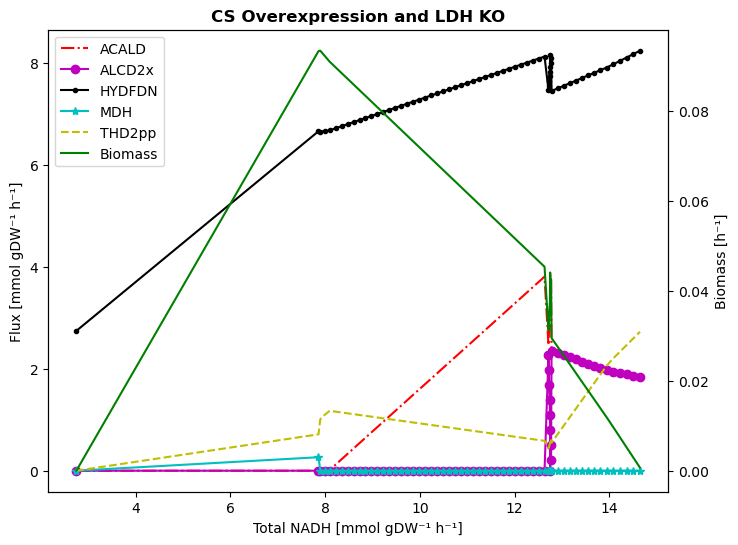

In [19]:
# Generation of the graph

fig, ax = plt.subplots(figsize=(8,6))

# Before plotting, we must sort the data frame by NADH concentration to improve data visualization.
df_CS_ko_graph = df_CS_ko_graph.sort_values(by = 'NADH Total',ascending=True)

f.plot_lines(df_CS_ko_graph,['r','m','k','c','y','g'],['-.','o-','.-','*-','--','-'],'CS Overexpression and LDH KO','upper left',ax)

fig.savefig('../Images/CS_LDH_KO.png',dpi=1200)

<div style='text-align: justify'>PS6</div>

In [20]:
# Creation of ACALD and LDH knockout scenario (PS7)

with model_anaero_H2_PFOR as m_CS_2:
    m_CS_2.reactions.get_by_id('ACALD_bw').bounds = (0,0)
    m_CS_2.reactions.get_by_id('LDH_D_bw').bounds = (0,0)
    upper_CS_2 = f.Max(m_CS_2,"CS_fw")

    PS7 = f.nadh_hyd(m_CS_2,{"CS_fw":upper_CS_2},0.1)
    
    df_CS_2 = PS7[0]

    df_CS_2_graph = df_CS_2.copy()
    df_CS_2_graph = df_CS_2_graph.loc[:, (df_CS_2 > 0.1).any(axis=0)]
    df_CS_2_graph.loc[:,'Biomass'] = df_CS_2.loc[:,'Biomass']

    h2_7 = PS7[1]

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


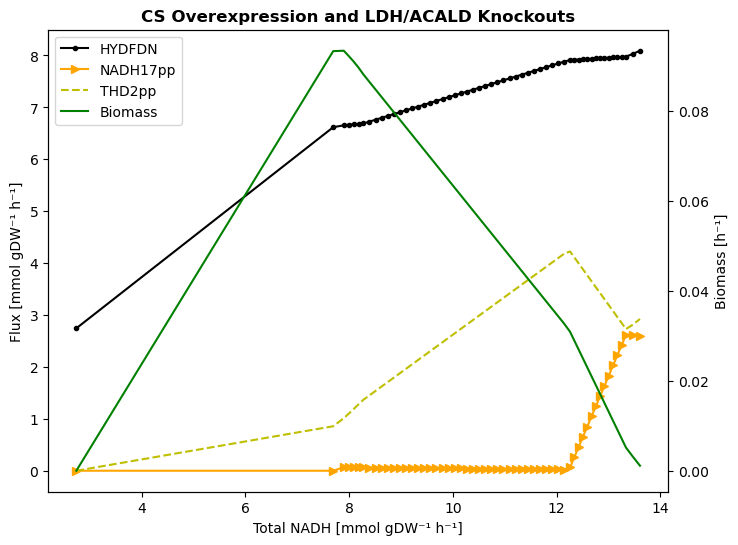

In [21]:
fig, ax = plt.subplots(figsize=(8,6))

f.plot_lines(df_CS_2_graph,['k','orange','y','g'],['.-','>-','--','-'],'CS Overexpression and LDH/ACALD Knockouts','upper left',ax)

fig.savefig('../Images/NADH_CS_ACALD_LDH_KO.png',dpi=1200)

<div style='text-align: justify'>PS7</div>

In [22]:
# Creation of ACALD, LDH and THD2pp knockout scenario (PS8)

with model_anaero_H2_PFOR as m_CS_3:
    m_CS_3.reactions.get_by_id('ACALD_bw').bounds = (0,0)
    m_CS_3.reactions.get_by_id('LDH_D_bw').bounds = (0,0)
    m_CS_3.reactions.get_by_id('THD2pp_fw').bounds = (0,0)
    
    upper_CS_3 = f.Max(m_CS_3,"CS_fw")

    solution = m_CS_3.optimize()

    if solution != None:
        
        PS8 = f.nadh_hyd(m_CS_3,{"CS_fw":upper_CS_3},0.1)
        
        df_CS_3 = PS8[0]
    
        df_CS_3_graph = df_CS_3.copy()
        df_CS_3_graph = df_CS_3_graph.loc[:, (df_CS_3 > 0.1).any(axis=0)]
        df_CS_3_graph.loc[:,'Biomass'] = df_CS_3.loc[:,'Biomass']
    
        h2_8 = PS8[1]

    else:
        print('Infeasible scenario')

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


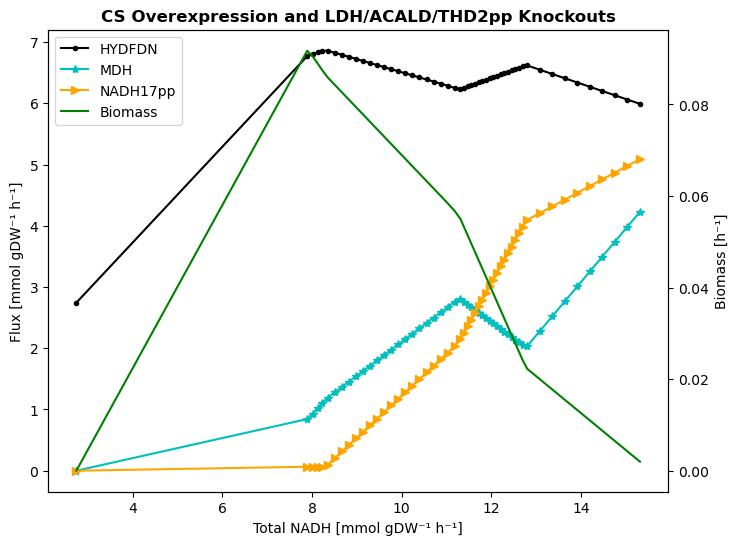

In [23]:
fig, ax = plt.subplots(figsize=(8,6))

f.plot_lines(df_CS_3_graph,['k','c','orange','g'],['.-','*-','>-','-'],'CS Overexpression and LDH/ACALD/THD2pp Knockouts','upper left',ax)

fig.savefig('../Images/NADH_CS_ACALD_LDH__THD_KO.png',dpi=1200)

PS8

### <b>General Considerations on HydABC/PFOR Model</b>

## 8.2 OGOR Model Analysis

In [5]:
# OGOR and HydABC model
model_anaero_H2_OGOR = load_json_model('../Models/EC_iCH360_H2_OGOR_25.json')

solution_OGOR_H2 = model_anaero_H2_OGOR.optimize()
solution_OGOR_H2

,fluxes,reduced_costs
NDPK5_fw,0.002788,-1.387779e-17
SHK3Dr_fw,0.039217,1.040834e-17
NDPK6_fw,0.002700,-2.220446e-16
NDPK8_fw,0.002700,2.775558e-17
DHORTS_fw,0.000000,-7.631694e-03
...,...,...
EX_h2_e_fw,0.000000,0.000000e+00
H2TPP_fw,0.000000,0.000000e+00
H2tex_fw,0.000000,0.000000e+00
OGOR_fw,0.000000,-5.058932e-02


### 8.2.1 NADH Synthesis Improvement and $H_2$ Production by HydABC

<div style='text-align: justify'><b>From here, for practical purposes, all simulations will be referred to by acronyms, composed of “OS” (referring to “OGOR Strain”) followed by a number. PDH overexpression will be the first simulation and, therefore, will be referred to as OS1. All subsequent analyses will follow this order.</b></div>

### <b>PPC Overexpression</b>

In [25]:
# Calculation of total NADH production, main enzymes involved on NADH consumption and biomass production after HydABC and OGOR expression

OS1 = f.nadh_hyd(model_anaero_H2_OGOR,{"PPC_fw":f.Max(model_anaero_H2_OGOR,"PPC_fw")},0.1)

df_PPC_OGOR = OS1[0]
h2_O1 = OS1[1]

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


In [26]:
# For better data visualization, we will remove enzymes that the maximum flux value is lower than 0.1
df_PPC_O_graph = df_PPC_OGOR.loc[:, (df_PPC_OGOR > 0.1).any(axis=0)]

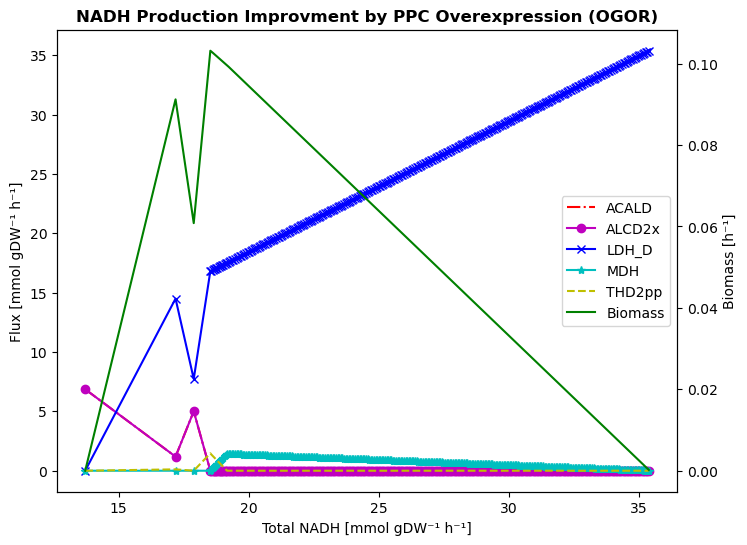

In [27]:
fig, ax = plt.subplots(figsize=(8,6))

# Before plotting, we must sort the data frame by NADH concentration to improve data visualization.
df_PPC_O_graph = df_PPC_O_graph.sort_values(by = 'NADH Total',ascending=True)

# Removing unconstant values of FBA
df_const = df_PPC_O_graph.copy()
df_const.drop(df_const.index[8], inplace=True)

color = ['g','r','m','b','c','y']
forms = ['-','-.','o-','x-','*-','--']
f.plot_lines(df_const,color,forms,'NADH Production Improvment by PPC Overexpression (OGOR)','center right',ax)

fig.savefig('../Images/NADH_OGOR_PPC.png',dpi=1200)

<div style='text-align: justify'> OS1: As indicated, PPC overexpression leads to LDH maximization, since this scenario represents, ultimately, wild-type anaerobic metabolism, given the inactivation of the $H_2$ production pathway. The alcoholic fermentation pathway appears to be active only at lower NADH levels. Beyond the threshold of 18 mmol/gDW/h, LDH becomes practically the only enzyme responsible for cofactor oxidation. In this context, NADH production reaches the highest levels observed in Part 6. Even so, the graph shows that HydABC remains inactive. This may be a consequence of OGOR inactivation, since this enzyme is not directly linked to PPC, unlike its relationship with CS. Thus, it is more likely that increased NADH availability requires HydABC activity to drive OGOR flux, rather than the reverse. Based on this, we will test different scenarios under PPC overexpression, all aiming to induce HydABC activity through increased NADH production combined with repression of competing NADH oxidation enzymes. Therefore, we first evaluate the effect of LDH knockout (OS2).</div>

In [28]:
# Generation of OS2 strain
with model_anaero_H2_OGOR as m_PPC_LDH:
    m_PPC_LDH.reactions.get_by_id('LDH_D_bw').bounds = (0,0)
    upper_PPC_LDH = f.Max(m_PPC_LDH,"PPC_fw")

    OS2 = f.nadh_hyd(m_PPC_LDH,{"PPC_fw":upper_PPC_LDH},0.1)
    
    df_PPC_LDH_KO = OS2[0]

    df_PPC_O_ko_graph = df_PPC_LDH_KO.copy()
    df_PPC_O_ko_graph = df_PPC_O_ko_graph.loc[:, (df_PPC_LDH_KO > 0.1).any(axis=0)]
    df_PPC_O_ko_graph.loc[:,'Biomass'] = df_PPC_LDH_KO.loc[:,'Biomass']

    h2_O2 = OS2[1]

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


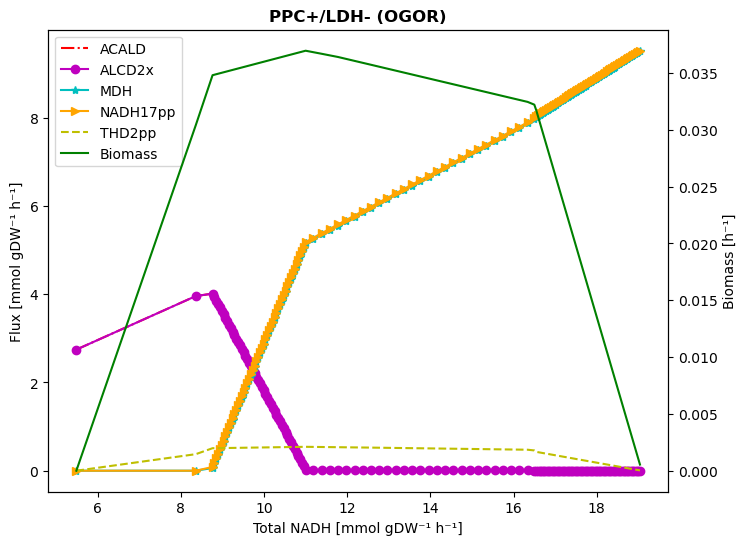

In [29]:
fig, ax = plt.subplots(figsize=(8,6))

color = ['r','m','c','orange','y','g']
forms = ['-.','o-','*-','>-','--','-']
f.plot_lines(df_PPC_O_ko_graph,color,forms,'PPC+/LDH- (OGOR)','upper left',ax)

fig.savefig('../Images/NADH_OGOR_PPC_LDH_KO.png',dpi=1200)

<div style='text-align: justify'> OS2: Once LDH is no longer able to operate, alcoholic fermentation is induced to function at lower NADH levels. However, as NADH concentration increases due to PPC overexpression, alcohol production is no longer sufficient to maintain redox balance. Thus, MDH and NADH17pp remain active at higher NADH production rates, acting as the only enzymes responsible for NADH consumption. HydABC is still not induced to oxidize NADH, mainly due to the implications of OGOR activity under anaerobic conditions. We now proceed to a more extreme scenario, in which ACALD, LDH, and MDH are all knocked out (OS3).</div>

In [30]:
with model_anaero_H2_OGOR as m_PPC_3:
    m_PPC_3.reactions.get_by_id('ACALD_bw').bounds = (0,0)
    m_PPC_3.reactions.get_by_id('LDH_D_bw').bounds = (0,0)
    m_PPC_3.reactions.get_by_id('MDH_bw').bounds = (0,0)
    
    upper_PPC_3 = f.Max(m_PPC_3,"PPC_fw")

    OS3 = f.nadh_hyd(m_PPC_3,{"PPC_fw":upper_PPC_3},0.1)
    display(OS3)

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


0

<div style='text-align: justify'> OS3: As indicated by the simulation, there is no growth in the constructed strain, suggesting that OGOR is not capable of indirectly mediating HydABC activity under high NADH production rates. Let us now proceed to the CS overexpression scenario, which seems to be more suitable for OGOR activation.</div>

### <b>CS Overexpression</b>

<div style='text-align: justify'> Since OGOR is directly related to CS, we expect a positive correlation between CS overexpression and OGOR activity. We first evaluate the simple scenario of CS overexpression without additional modifications (OS4).</div>

In [31]:
# Calculation of total NADH production, main enzymes involved on NADH consumption and biomass production after HydABC and OGOR expression

OS4 = f.nadh_hyd(model_anaero_H2_OGOR,{"CS_fw":f.Max(model_anaero_H2_OGOR,"CS_fw")},0.1)

df_CS_OGOR = OS4[0]
h2_O4 = OS4[1]

In [32]:
# For better data visualization, we will remove enzymes that the maximum flux value is lower than 0.1
df_CS_O_graph = df_CS_OGOR.loc[:, (df_CS_OGOR > 0.1).any(axis=0)]

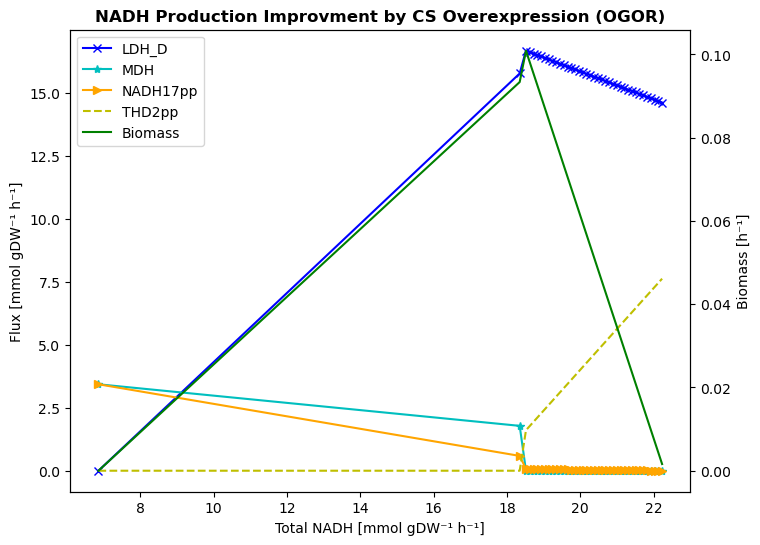

In [33]:
fig, ax = plt.subplots(figsize=(8,6))

color = ['g','b','c','orange','y']
forms = ['-','x-','*-','>-','--']
f.plot_lines(df_CS_O_graph,color,forms,'NADH Production Improvment by CS Overexpression (OGOR)','upper left',ax)

fig.savefig('../Images/NADH_OGOR_CS.png',dpi=1200)

<div style='text-align: justify'> OS4: Contrary to expectations, CS overexpression alone is not sufficient to induce OGOR activity and, consequently, HydABC. As shown in the graph, LDH remains the main enzyme responsible for NADH oxidation, while ACALD is not activated in this scenario. With regard to biomass production, we observe that after the inflection point at approximately 18 mmol/gDW/h of total NADH produced, biomass decreases sharply, accompanied by a reduction in LDH activity. Thus, to promote HydABC flux, we will simulate the knockout of LDH (OS5).</div>

In [34]:
with model_anaero_H2_OGOR as m_CS_LDH:
    m_CS_LDH.reactions.get_by_id('LDH_D_bw').bounds = (0,0)

    upper_CS_LDH = f.Max(m_CS_LDH,"CS_fw")

    OS5 = f.nadh_hyd(m_CS_LDH,{"CS_fw":upper_CS_LDH},0.1)
    
    df_CS_LDH_KO = OS5[0]

    # Using the previous filters, biomass is excluded; therefore, we must ensure that the biomass column is retained in the final data frame
    df_CS_LDH_ko_graph = df_CS_LDH_KO.copy()
    df_CS_LDH_ko_graph = df_CS_LDH_ko_graph.loc[:, (df_CS_LDH_ko_graph > 0.1).any(axis=0)]
    df_CS_LDH_ko_graph.loc[:,'Biomass'] = df_CS_LDH_KO['Biomass']
    
    h2_O5 = OS5[1]

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


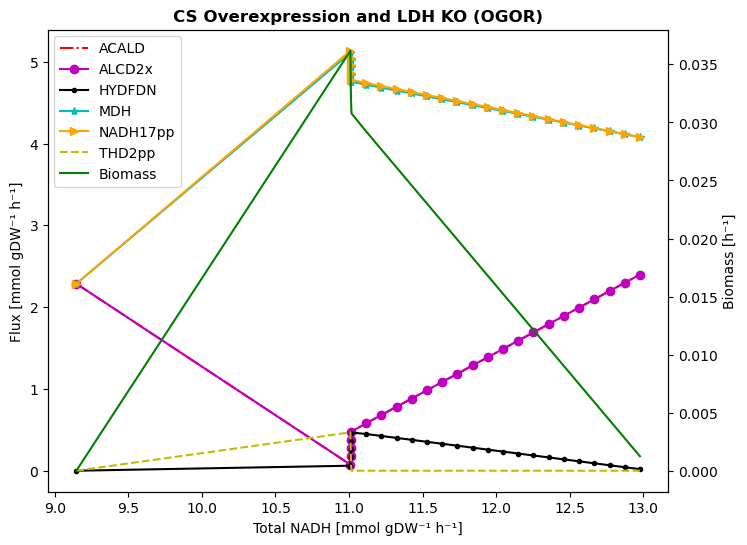

In [35]:
# Generation of the graph

fig, ax = plt.subplots(figsize=(8,6))

f.plot_lines(df_CS_LDH_ko_graph,['r','m','k','c','orange','y','g'],['-.','o-','.-','*-','>-','--','-'],'CS Overexpression and LDH KO (OGOR)',(0.01,0.66),ax)

fig.savefig('../Images/NADH_CS_LDH_KO_OGOR.png',dpi=1200)

<div style='text-align: justify'> OS5: At lower NADH production rates, ACALD remains the primary enzyme responsible for NADH oxidation, supporting biomass maximization. In parallel with the increase in ACALD flux, NADH dehydrogenase (NADH17pp) and MDH also increase at similar rates, causing their profiles to overlap in the graph. In contrast, ALCD2x flux decreases at low NADH levels, showing an inverse relationship with ACALD. This suggests that, for biomass maximization in <i>E. coli</i> after heterologous expression of OGOR and HydABC, the final product of ACALD activity tends to be acetaldehyde rather than ethanol. After biomass reaches its maximum yield (considerably lower than in the wild-type anaerobic strain) ACALD flux begins to decline, followed by NADH17pp and MDH. Conversely, ALCD2x increases at higher NADH production rates. Regarding HydABC, a low flux is observed near the biomass inflection point, indicating a limited potential for $H_2$ production. However, as total NADH production increases, HydABC flux decreases. These results indicate that OGOR has a substantially lower capacity to stimulate $H_2$ production compared with PFOR, leading not only to reduced $H_2$ formation but also to lower maximum biomass yields under CS or PDH overexpression. To further evaluate how HydABC flux is affected by the inactivation of enzymes induced in OS5, we will construct OS6, a strain including additional knockouts of ACALD and MDH, which show high activity under LDH knockout conditions. </div>

In [36]:
with model_anaero_H2_OGOR as m_CS_O3:
    m_CS_O3.reactions.get_by_id('LDH_D_bw').bounds = (0,0)
    m_CS_O3.reactions.get_by_id('ACALD_bw').bounds = (0,0)
    m_CS_O3.reactions.get_by_id('MDH_bw').bounds = (0,0)

    sol_3_CS = m_CS_O3.optimize()
    print(f'Solution at LDH/ACALD/MDH knockouts and CS overexpression: {sol_3_CS.objective_value}')

Solution at LDH/ACALD/MDH knockouts and CS overexpression: None


/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


<div style='text-align: justify'> As indicated by the simulation, there is no growth in the constructed strain, suggesting that OGOR cannot indirectly mediate NADH consumption through HydABC as effectively as PFOR. It is noteworthy, however, that the only observable flux for HydABC (and consequently for OGOR) occurs in a scenario very similar to the one that yields high HydABC flux in the PFOR case, namely CS overexpression with LDH knockout. Therefore, to conclude Chapter 8, we will analyze how HydABC activity is maximized when both PFOR and OGOR are present in the model and CS is overexpressed with LDH knocked out. For this analysis, OGOR will be introduced into model_anaero_H2_OGOR (PO0), as this represents the simplest approach for incorporating the enzyme. The total enzyme pool supply will not be modified, as previously discussed in Chapter 7, allowing OGOR to compete with native enzymes for enzyme allocation.</div>

## 8.3 PFOR/OGOR Model Analysis

### 8.3.1 Introduction of OGOR on PFOR Model

In [16]:
# Adding OGOR reaction to model_anaero_H2_PFOR_05
model_anaero_H2_PFOR_OGOR = model_anaero_H2_PFOR.copy()

OGOR_fw_05 = cobra.Reaction('OGOR_fw')
OGOR_bw_05 = cobra.Reaction('OGOR_bw')
model_anaero_H2_PFOR_OGOR.add_reactions([OGOR_fw_05,OGOR_bw_05])

# Define reaction equations
OGOR_fw_05.reaction = '1.0 akg_c + 1.0 coa_c + 1.0 fdxox_c + 0.009831276 enzyme_pool -> 1.0 succoa_c + 1.0 co2_c + 1.0 fdxrd_c + 1.0 h_c'
OGOR_bw_05.reaction = '1.0 succoa_c + 1.0 co2_c + 1.0 fdxrd_c + 1.0 h_c + 0.235950617 enzyme_pool -> 1.0 akg_c + 1.0 coa_c + 1.0 fdxox_c'

Read LP format model from file /tmp/tmpyoy0njab.lp
Reading time = 0.00 seconds
: 310 rows, 1022 columns, 4870 nonzeros


In [17]:
# Analysis of biomass production and fluxes of introduced enzymes

# model_anaero_H2_OGOR_1
print("model_anaero_H2_PFOR_OGOR solution:\n")
sol_PFOR_OGOR = model_anaero_H2_PFOR_OGOR.optimize()
display(sol_PFOR_OGOR)

model_anaero_H2_PFOR_OGOR solution:



,fluxes,reduced_costs
NDPK5_fw,0.002864,-3.252607e-18
SHK3Dr_fw,0.040289,4.702727e-18
NDPK6_fw,0.002774,1.526557e-16
NDPK8_fw,0.002774,-7.589415e-19
DHORTS_fw,0.000000,-7.838896e-03
...,...,...
H2TPP_fw,0.921608,0.000000e+00
H2tex_fw,0.921608,0.000000e+00
PFOR_fw,0.460804,0.000000e+00
OGOR_fw,0.000000,-2.731303e-02


In [39]:
# Saving model_anaero_H2_PFOR_OGOR_05 for further analysis
#save_json_model(model_anaero_H2_PFOR_OGOR,'../Models/EC_iCH360_H2_PFOR_OGOR_25.json')

<div style='text-align: justify'> As expected, OGOR introduction does not change model behavior, remaining identical to that observed in Section 8.1. Thus, we focus on the most relevant scenario: CS overexpression with LDH knockout. Given the potential of ACALD to consume NADH, we will also remove this enzyme for the simulation, creating strain PO1 (“PFOR OGOR 1”), composed of heterologous expression of OGOR and HydABC, the introduction of PFOR, and the knockout of both ACALD and LDH.</div>

### 8.3.2 HydABC Flux Improvment on PFOR/OGOR Model

In [40]:
# Creation of PO1

with model_anaero_H2_PFOR_OGOR as m_CS_PO1:
    m_CS_PO1.reactions.get_by_id('ACALD_bw').bounds = (0,0)
    m_CS_PO1.reactions.get_by_id('LDH_D_bw').bounds = (0,0)
    
    upper_CS_PO1 = f.Max(m_CS_PO1,"CS_fw")

    PO1 = f.nadh_hyd(m_CS_PO1,{"CS_fw":upper_CS_PO1},0.1)
    
    df_CS_PO1 = PO1[0]

    df_CS_PO1_graph = df_CS_PO1.copy()
    df_CS_PO1_graph = df_CS_PO1_graph.loc[:, (df_CS_PO1 > 0.1).any(axis=0)]
    df_CS_PO1_graph.loc[:,'Biomass'] = df_CS_PO1['Biomass']

    h2_PO1 = PO1[1]

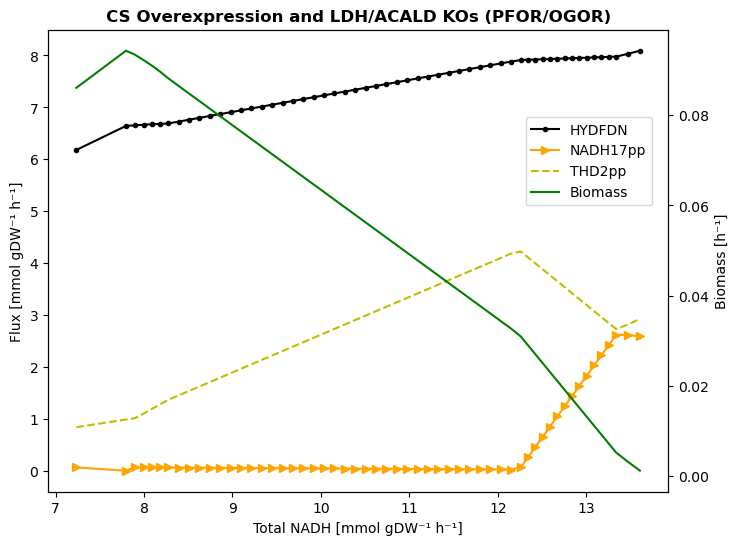

In [41]:
# Generation of the graph

fig, ax = plt.subplots(figsize=(8,6))

f.plot_lines(df_CS_PO1_graph,['k','orange','y','g'],['.-','>-','--','-'],'CS Overexpression and LDH/ACALD KOs (PFOR/OGOR)',(0.77,0.62),ax)

fig.savefig('../Images/NADH_CS_LDH_ACALD_KO_OGOR_PFOR.png',dpi=1200)

<div style='text-align: justify'> PO1: Unfortunately, OGOR does not appear to improve HydABC yields beyond those observed in PS2. In fact, its introduction into the model leads to a faster decline in biomass compared with PS2. Thus, CS overexpression seems insufficient to enhance HydABC flux when both OGOR and PFOR are expressed. To better understand the impact of CS on OGOR, as well as the effect of OGOR on CS, we will use the f.pfor_ogor function to visualize how both enzymes are correlated in the PFOR/OGOR model.</div>

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


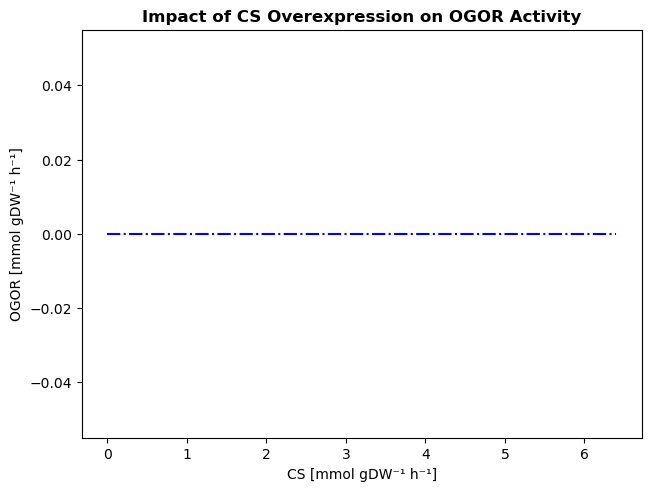

In [42]:
# Visualization of CS overexpression over OGOR activity

f.pfor_ogor(model_anaero_H2_PFOR_OGOR,
            "CS_fw",
            "OGOR_fw",
            f.Max(model_anaero_H2_PFOR_OGOR,"CS_fw"),
            0.1,
            "Impact of CS Overexpression on OGOR Activity")

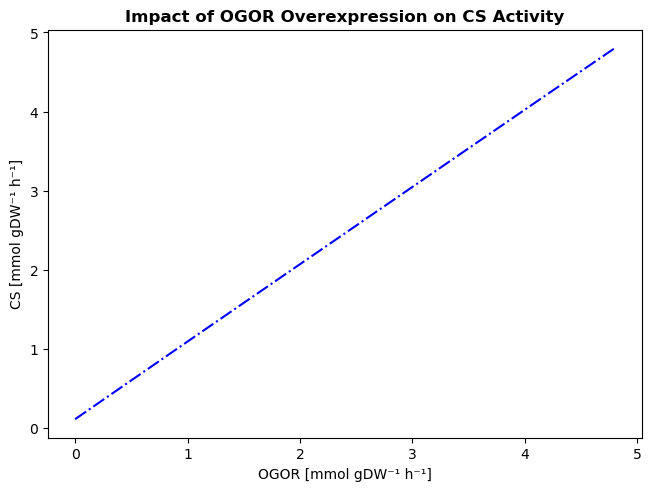

In [43]:
# Visualization of OGOR overexpression over CS activity

f.pfor_ogor(model_anaero_H2_PFOR_OGOR,
            "OGOR_fw",
            "CS_fw",
            f.Max(model_anaero_H2_PFOR_OGOR,"OGOR_fw"),
            0.1,
            "Impact of OGOR Overexpression on CS Activity")

<div style='text-align: justify'> <b>CS Overexpression:</b> As indicated by the first graph, CS doesn't impacts OGOR.</div><br>

<div style='text-align: justify'> <b>OGOR Overexpression:</b> In contrast to the CS overexpression scenario, OGOR overexpression is directly associated with CS induction. This can be explained by the requirement of 2-oxoglutarate for OGOR activity; in <i>E. coli</i> metabolism, CS induction promotes the entry into the oxidative branch of the TCA cycle, favoring the production of this metabolite. Based on this, we can define an interesting strain (PO2), in which OGOR is not induced by CS; instead, CS is induced as a consequence of OGOR activity. With this approach, we aim to maximize $H_2$ production by HydABC, such that OGOR overexpression promotes not only $Fd_{red}$ generation, but also indirectly enhances NADH production through CS activity.</div>

In [18]:
# Creation of PO2

with model_anaero_H2_PFOR_OGOR as m_OGOR_PO2:
    
    upper_OGOR_PO2 = f.Max(m_OGOR_PO2,"OGOR_fw")

    PO2 = f.nadh_hyd(m_OGOR_PO2,{"OGOR_fw":upper_OGOR_PO2},0.1)
    
    df_OGOR_PO2 = PO2[0]
    df_OGOR_PO2_graph = df_OGOR_PO2.loc[:, (df_OGOR_PO2 > 0.1).any(axis=0)]

    h2_PO2 = PO2[1]

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


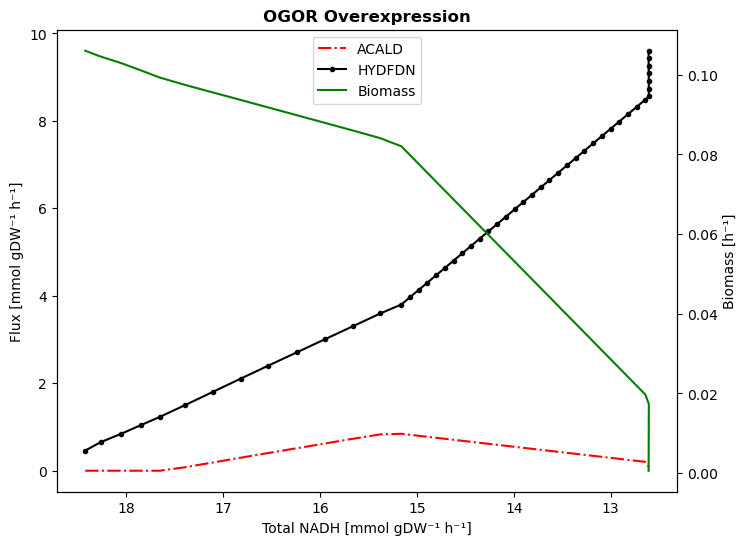

In [23]:
# Generation of the graph

fig, ax = plt.subplots(figsize=(8,6))

#df_OGOR_PO2_graph = df_OGOR_PO2_graph.sort_values(ascending=True, by=['NADH Total'])

f.plot_lines(df_OGOR_PO2_graph,['g','r','k'],['-','-.','.-'],'OGOR Overexpression','upper center',ax)
ax.invert_xaxis()

#fig.savefig('../Images/OGOR_Over.png',dpi=1200)

<div style='text-align: justify'> PO2: Through OGOR overexpression, NADH production reaches lower yields, similarly to that observed in strain PS1. <b>It is important to note, however, that for this graph specifically, the x-axis must be inverted, representing the reduction in total NADH production under OGOR overexpression.</b> This may help explain the behavior of the HydABC complex, since, as shown in previous simulations, HydABC is highly sensitive to elevated cofactor levels. It is also noteworthy that biomass decreases at a slower rate compared to strain PS2, making strain PO2 more suitable in a scenario of balanced biomass and HydABC activity. Thus, as the results indicate, OGOR overexpression also represents a viable strategy for $H_2$ production by HydABC, following a mechanism similar to that observed in strains PS5, PS6, PS7 and PS8, namely through the induction of CS. We now assess whether PFOR is also induced under OGOR overexpression.</div>

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


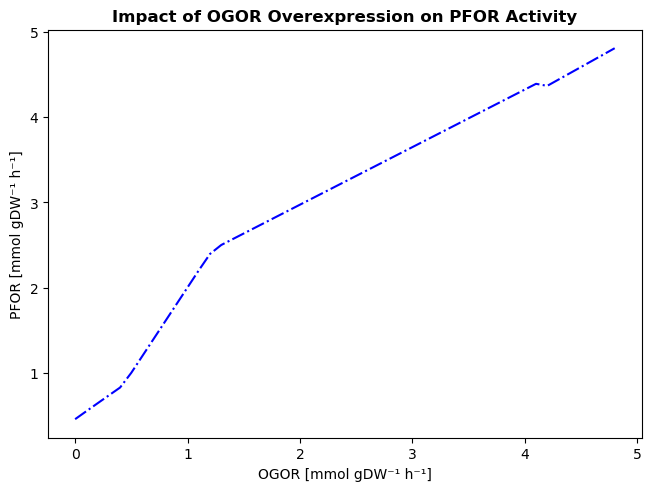

In [46]:
# Visualization of OGOR overexpression over PFOR activity

f.pfor_ogor(model_anaero_H2_PFOR_OGOR,
            "OGOR_fw",
            "PFOR_fw",
            f.Max(model_anaero_H2_PFOR_OGOR,"OGOR_fw"),
            0.1,
            "Impact of OGOR Overexpression on PFOR Activity")

<div style='text-align: justify'> As demonstrated, PFOR is induced by OGOR overexpression. Thus, OGOR appears to act as an “additional support” for $Fd_{red}$ production, since its overexpression leads to an increase in PFOR flux, allowing both enzymes to operate toward the same objective, reducing $Fd_{ox}$. This behavior may explain the improvement in HydABC flux, as the complex is now supported by both enzymes. To confirm this hypothesis, we will replicate the analysis in the OGOR-only model by overexpressing OGOR and evaluating how HydABC responds when only OGOR is enhanced (OS6).</div>

In [11]:
# Creation of OS6

with model_anaero_H2_OGOR as m_OGOR_OS6:
    
    upper_OGOR_OS6 = f.Max(m_OGOR_OS6,"OGOR_fw")

    OS6 = f.nadh_hyd(m_OGOR_OS6,{"OGOR_fw":upper_OGOR_OS6},0.1)
    
    df_OGOR_OS6 = OS6[0]
    df_OGOR_OS6_graph = df_OGOR_OS6.loc[:, (df_OGOR_OS6 > 0.1).any(axis=0)]

    h2_OS6 = OS6[1]

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


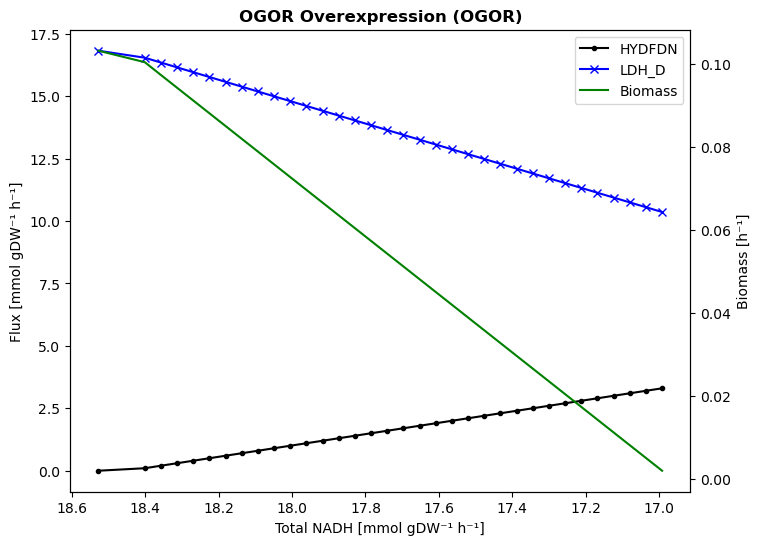

In [15]:
# Generation of the graph

fig, ax = plt.subplots(figsize=(8,6))

#df_OGOR_OS6_graph = df_OGOR_OS6_graph.sort_values(ascending=True, by=['NADH Total'])


f.plot_lines(df_OGOR_OS6_graph,['g','k','b'],['-','.-','x-'],'OGOR Overexpression (OGOR)','upper right',ax)
ax.invert_xaxis()

#fig.savefig('../Images/OGOR_Over_OGOR_only.png',dpi=1200)

<div style='text-align: justify'> OS6: From this, we conclude that OGOR overexpression alone is not sufficient to improve HydABC flux at high levels. <b>It is important to note, however, that for this graph specifically, the x-axis must be inverted, representing the reduction in total NADH production under OGOR overexpression.</b> In this context, OGOR overexpression leads to an increase in HydABC flux, as expected. However, in contrast to PO2, total NADH production decreases, followed by a rapid decline in biomass production. Therefore, it is evident that OGOR overexpression can only support maximal HydABC flux when PFOR is simultaneously expressed. PFOR plays a central role in maintaining biomass, enabling sustained HydABC activity. In addition, OGOR acts as an auxiliary source of $Fd_{red}$ and promotes CS flux, which indirectly influences total NADH production. Together, these enzymes enable a balance between lower NADH production, high HydABC flux, and viable biomass yields.</div><br>

<div style='text-align: justify'> <b>Taking into account the results obtained in this chapter, it is of extreme importance to assess an emerging question: What would happen if both PPC and OGOR were overexpressed in the model?</b> We can hypothesize that PPC and OGOR could cooperate to improve both NADH and $Fd$ availability to the hydrogenase complex, enhancing HydABC activity to values even higher than those observed in strain PS1. To do this, we must first determine the optimal flux values for both enzymes be overexpressed.</div>

In [49]:
r_imp = ['PDH_fw','CS_fw','ACONTa_fw','ACONTa_bw',
         'ACONTb_fw','ACONTb_bw','ICDHyr_fw','ICDHyr_bw',
         'AKGDH_fw','SUCOAS_fw','SUCOAS_bw','FUM_fw','FUM_bw',
         'FRD2_fw','ICL_fw','ICL_bw','MALS_fw','MDH_fw', 'MDH_bw']

ppc_max = f.Max(model_anaero_H2_PFOR_OGOR,'PPC_fw')
ogor_max = f.Max(model_anaero_H2_PFOR_OGOR,'OGOR_fw')

@interact (
    ppc_fw = (0.0,ppc_max,0.001),
    ogor_fw = (0.0,ogor_max,0.001),
)

# 0.1105232674676028 is the normal flux on E. coli under anaerobic conditions
# For PDH and FUM, the value is equal to 0

def changes(ppc_fw = 0.4125075038638759,
            ogor_fw = 0.0):

    dict_aux = {l:[] for l in r_imp}
    dict_aux['NADH'] = []
    dict_aux['Biomass'] = []

    with model_anaero_H2_PFOR_OGOR as model:
        
        try:
            if ppc_fw != 0.4125075038638759:
                model.reactions.get_by_id('PPC_fw').bounds = (ppc_fw,ppc_fw)
            if ogor_fw != 0.0:
                model.reactions.get_by_id('OGOR_fw').bounds = (ogor_fw,ogor_fw)
            
            solution = model_anaero_H2_PFOR_OGOR.optimize()
    
            if solution.objective_value is not None:
                    
                for reaction in r_imp:
                    dict_aux[reaction].append(solution.fluxes[reaction])
        
                dict_aux['Biomass'].append(solution.objective_value)
                dict_aux['NADH'].append(sum(model_anaero_H2_PFOR_OGOR.metabolites.get_by_id('nadh_c').summary(solution).producing_flux['flux']))
        
            df = pd.DataFrame(dict_aux)
            display(df)
            
        except Exception as e:
            print(f"Error: {e}")

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


interactive(children=(FloatSlider(value=0.4125075038638759, description='ppc_fw', max=28.550000000001663, step…

<div style='text-align: justify'> Through interactive modification of OGOR and PPC flux, we observe that at the maximal fluxes of 14 mmol/gDW/h for PPC and 2.5 mmol/gDW/h for OGOR, NADH production suppress 16 mmol/gDW/h, wchich is higher than the maximal NADH production founded only by PPC overexpression on strain PS1. This way, these values of flux will be set as the maximum upper bound for the enzymes on f.nadh_hyd, as follow:</div>

In [28]:
# Creation of PO3

with model_anaero_H2_PFOR_OGOR as m_OGOR_PO3:

    PO3 = f.nadh_hyd(m_OGOR_PO3,{"OGOR_fw":2.5, "PPC_fw":14},0.1)
    
    df_OGOR_PO3 = PO3[0]

    df_OGOR_PO3_graph = df_OGOR_PO3.copy()
    df_OGOR_PO3_graph = df_OGOR_PO3_graph.loc[:, (df_OGOR_PO3 > 0.1).any(axis=0)]
    df_OGOR_PO3_graph.loc[:,'Biomass'] = df_OGOR_PO3.loc[:,'Biomass']

    h2_PO3 = PO3[1]

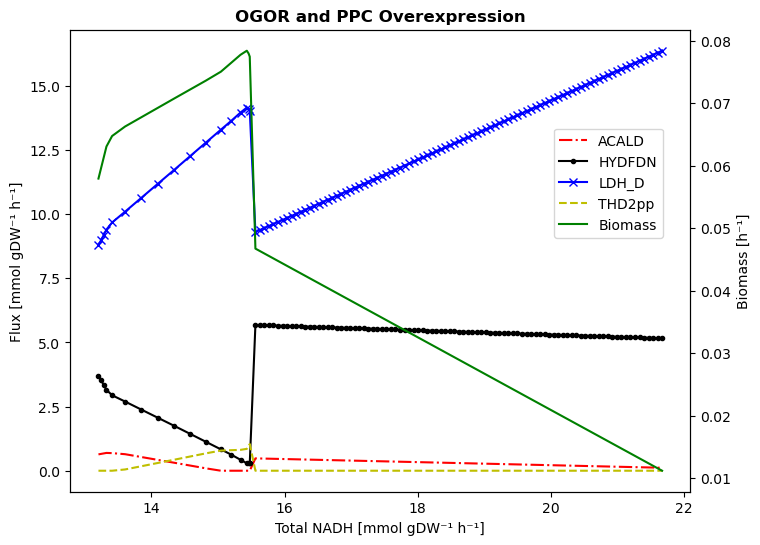

In [29]:
# Generation of the graph

fig, ax = plt.subplots(figsize=(8,6))

df_const = df_OGOR_PO3_graph.copy()

df_const.drop(df_const.index[17:49], inplace=True)
df_const = df_const.sort_values(ascending=True, by=['NADH Total'])

f.plot_lines(df_const,['r','k','b','y','g'],['-.','.-','x-','--','-'],'OGOR and PPC Overexpression',(0.78,0.55),ax)

#fig.savefig('../Images/OGOR_PFOR_PPC.png',dpi=1200)

<div style='text-align: justify'> As indicated, HydABC flux is also improved by PPC and OGOR overexpression, but to a lower extent than that observed in strain PS2. Regarding biomass production, we note a reduction in its maximum synthesis capacity, reaching approximately 0.08 h⁻¹. Again, lactic acid fermentation seems to be preferable to alcohol fermentation, reinforcing previous results. Nonetheless, the most interesting behavior to consider is the ability of HydABC to remain active at higher NADH levels than previously observed. Thus, although it can utilize higher amounts of NADH, the combined induction of PPC and OGOR does not appear to be the most effective strategy for improving HydABC activity under anaerobic conditions, given the negative impact on growth rate and the lower maximum $H_2$ production compared to strain PS2.</div>

In [26]:
# Creation of PO4

with model_anaero_H2_PFOR_OGOR as m_OGOR_PO4:

    m_OGOR_PO4.reactions.get_by_id('LDH_D_bw').bounds = (0,0)
    
    PO4 = f.nadh_hyd(m_OGOR_PO4,{"OGOR_fw":2.5, "PPC_fw":14},0.1)
    
    df_OGOR_PO4 = PO4[0]

    df_OGOR_PO4_graph = df_OGOR_PO4.copy()
    df_OGOR_PO4_graph = df_OGOR_PO4_graph.loc[:, (df_OGOR_PO4 > 0.1).any(axis=0)]
    df_OGOR_PO4_graph.loc[:,'Biomass'] = df_OGOR_PO4.loc[:,'Biomass']

    h2_PO4 = PO4[1]

/home/cristian/.conda/envs/cnapy-1.2.4/lib/python3.10/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


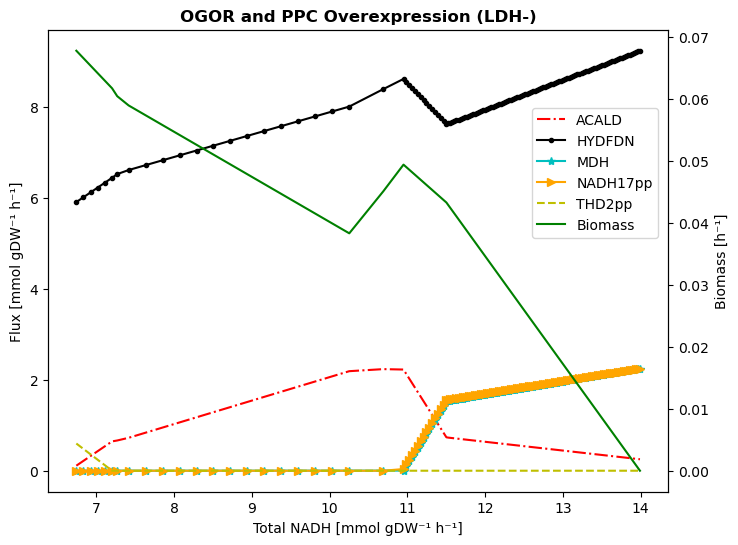

In [27]:
# Generation of the graph

fig, ax = plt.subplots(figsize=(8,6))

df_OGOR_PO4_graph.drop(df_OGOR_PO4_graph.index[0:5], inplace=True)
df_OGOR_PO4_graph = df_OGOR_PO4_graph.sort_values(ascending=True, by=['NADH Total'])

f.plot_lines(df_OGOR_PO4_graph,['r','k','c','orange','y','g'],['-.','.-','*-','>-','--','-'],'OGOR and PPC Overexpression (LDH-)',(0.78,0.55),ax)

fig.savefig('../Images/OGOR_PFOR_PPC_LDH.png',dpi=1200)

## 8.4 Final Comparation Between Best Strains Generated

<div style='text-align: justify'> Closing Chapter 8, we now compare how $H_2$ production flux varies among the best generated strains, considering both total units exported to the extracellular medium (represented by the reaction ‘EX_h2_e_fw’) and the yield of $H_2$ per mole of glucose consumed (calculated as ‘EX_h2_e_fw’ / ‘EX_glc__D_e_bw’):</div>

<b>PFOR Model:</b>
<ul>
    <li><b>PS1:</b> PPC Overexpression;</li>
    <li><b>PS2:</b> PPC overexpression and LDH knockout;</li>
    <li><b>PS5:</b> CS Overexpression;</li>
    <li><b>PS6:</b> CS overexpression and LDH knockout;</li>
    <li><b>PS7:</b> CS overexpression and both ACALD and LDH knockouts.</li>
    <li><b>PS8:</b> CS overexpression and ACALD, LDH and THD2pp knockouts.</li>
</ul>

<b>OGOR Model: None</b>

<b>PFOR/OGOR Model:</b>
<ul>
    <li><b>PO1:</b> CS Overexpression and both ACALD and LDH knockouts;</li>
    <li><b>PO2:</b> OGOR overexpression;</li>
    <li><b>PO3:</b> OGOR and PPC overexpression.</li>
    <li><b>PO4:</b> OGOR and PPC overexpression and LDH knockout.</li>
</ul>

<div style='text-align: justify'>To visualize how $H_2$ behaves in each strain, we will plot boxplot graphs for $H_2$ production obtained in each simulation, considering both the raw HydABC flux and the yield of $H_2$ produced (moles of $H_2$ produced per mole of glucose consumed). With this, we expect to visualize how HydABC flux varies by condition and whether the observed flux is followed by a corresponding production yield.</div>

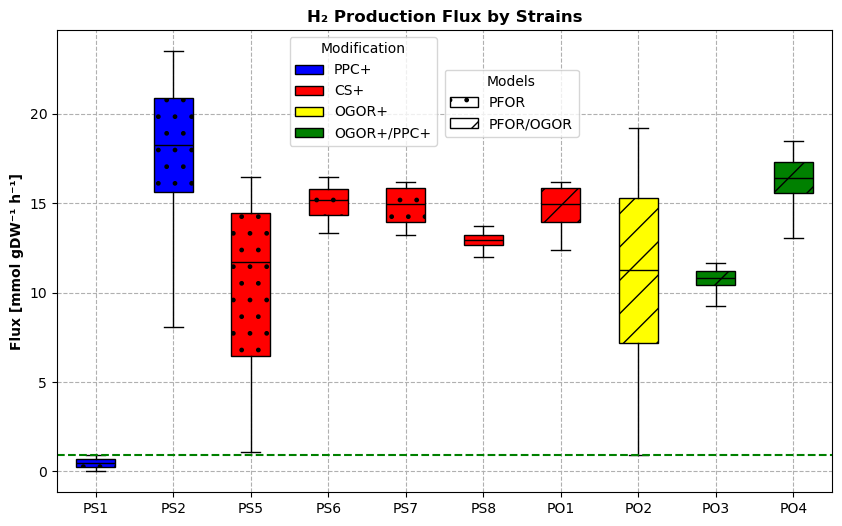

In [54]:
# Plotting HydABC fluxes per strain

data = [h2_1['H2'], h2_2['H2'], h2_5['H2'], h2_6['H2'], h2_7['H2'], h2_8['H2'],
        h2_PO1['H2'], h2_PO2['H2'], h2_PO3['H2'], h2_PO4['H2']]

colors = ['blue', 'blue', 'red', 'red', 'red','red',
          'red', 'yellow', 'green', 'green']

patterns = ['.', '.', '.', '.', '.', '.',
            '/', '/', '/', '/']

tick_label = ['PS1', 'PS2', 'PS5', 'PS6', 'PS7', 'PS8',
              'PO1', 'PO2', 'PO3', 'PO4']

f.boxplot(data, 
          colors, 
          'H₂ Production Flux by Strains', 
          'Flux [mmol gDW⁻¹ h⁻¹]',
          tick_label,
          patterns,
          h2_0,
          [(0.3,0.75),(0.5,0.77)])

<div style='text-align: justify'> Concluding the analyses of the PFOR/HydABC model, we can observe that, as expected from previous results, PPC is the main enzyme responsible for maximizing $H_2$ production by the HydABC complex heterologously expressed in <i>E. coli</i> under anaerobic conditions. It is also indicated on the graph the corresponding value for $H_2$ production of strain PS0, by the green dashed horizontal line at 0.9216 mmol/gDW/h of HydABC flux. By direct comparison with this line, we observe that PPC overexpression strain is by far the most indicated for HydABC flux improvement in <i>E. coli</i>, wheter on PFOR or OGOR/PFOR models. Therefore, PPC represents an excellent starting point for <i>in vitro</i> experiments aimed at maximizing biohydrogen production in the bacterium. Let us now visualize whether this behavior in HydABC flux is reflected in $H_2$ production yields.</div>

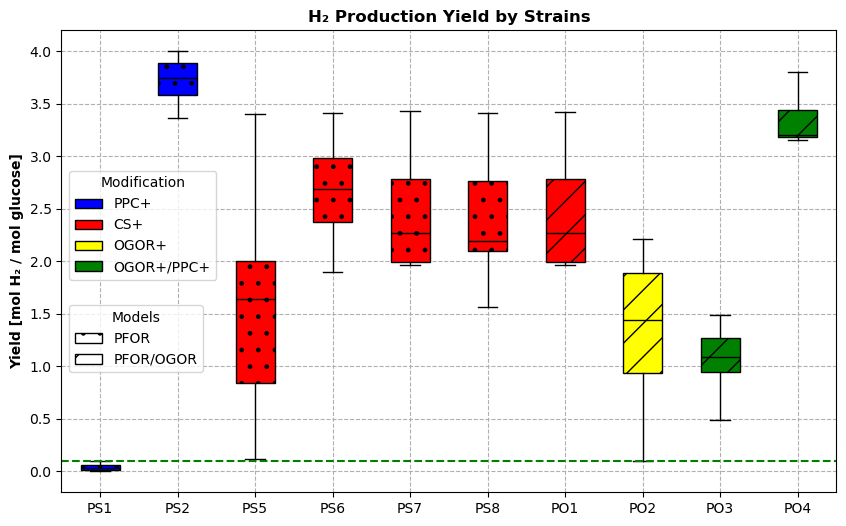

In [55]:
# Plotting H2 yields by strain
data = [h2_1, h2_2, h2_5, h2_6, h2_7, h2_8,
        h2_PO1, h2_PO2, h2_PO3, h2_PO4]

data_final = [np.array(i['H2'])/np.array(i['Glucose']) for i in data]

colors = ['blue', 'blue', 'red', 'red', 'red','red',
          'red', 'yellow', 'green', 'green']

patterns = ['.', '.', '.', '.', '.', '.',
            '/', '/', '/', '/']

tick_label = ['PS1', 'PS2', 'PS5', 'PS6', 'PS7', 'PS8',
              'PO1', 'PO2', 'PO3', 'PO4']

f.boxplot(data_final, 
          colors, 
          'H₂ Production Yield by Strains', 
          'Yield [mol H₂ / mol glucose]',
          tick_label,
          patterns,
          yield_wild_type,
          [(0.01,0.46),(0.01,0.26)])

<div style='text-align: justify'> It is noteworthy that the threshold of 4 mol $H_2$ / mol glucose appears to represent the upper limit for $H_2$ production by the bacterium through HydABC, as indicated by the maximum values achieved across the strains.</div>

<div style='text-align: justify'><b>$H_2$ Total Flux:</b> <b>As demonstrated, HydABC is highly sensitive to elevated NADH fluxes and is only able to sustain efficient $H_2$ production at relatively low cofactor levels. From the analysis of PPC, its overexpression increases NADH production within a range that still allows HydABC to operate efficiently, since biomass declines at higher NADH levels. Additionally, with OGOR introduction alongside PFOR, OGOR overexpression leads to CS induction, allowing both NADH and $Fd_{red}$ to be produced at favorable rates for HydABC maximization. Overall, these results suggest that, for maximizing HydABC flux in <i>E. coli</i> metabolism, PPC overexpression is a key strategy, whether as a single modification or coupled with OGOR overexpression. However, NADH maximization is not directly associated with improved $H_2$ production under anaerobic conditions. As observed, HydABC flux is improved within lower ranges of NADH production. Beyond approximately 18 mmol/gDW/h of NADH (typical of wild-type anaerobic conditions), activation of alternative NADH-consuming pathways becomes necessary. Furthermore, the model consistently activates alternative NADH consumption pathways to cope with high cofactor concentrations, suggesting that HydABC alone is not capable of maintaining a stable NAD⁺/NADH ratio at elevated levels. Thus, PPC represents a good starting point for HydABC maximization when heterologously expressed in <i>E. coli</i> metabolism. However, it is important to note that this enzyme is not capable of oxidizing NADH at rates comparable to native fermentation pathways, requiring the maintenance of controlled cofactor levels to maximize enzymatic efficiency.</b></div><br>

<div style='text-align: justify'><b>$H_2$ Yield:</b> Although they show an increase in $H_2$ production yield, this is still not sufficient to exceed the theoretical limit of 4 moles of $H_2$ per mole of glucose consumed during dark fermentation (<a href="https://doi.org/10.1128/br.41.1.100-180.1977">Thauer et al., 1977</a>).<b> Regarding PS2, we can suggest that PPC overexpression and LDH knockout is highly recommended for maximizing $H_2$ production yield, as it enhances $H_2$ export without requiring high glucose uptake. Additionally, considering the PFOR/OGOR model, we can infer that OGOR overexpression results in a coupled increase of both NADH and $Fd_{red}$ concentrations, thereby supporting the maximization of both HydABC flux and $H_2$ yield, also by LDH knockout. However, if surpassing Thauer's limit is the main objective of the experiment, HydABC is not the most suitable candidate when heterologously expressed in <i>E. coli</i> metabolism, making other systems more promising.</b></b></div><br>

<div style='text-align: justify'>Finally, concluding the analysis of Part 8, we will now assess the correlation between $H_2$ production yields and biomass production, highlighting how these two parameters influence each other for the best-performing strains in $H_2$ production yields (PS2 and PO3).</div>

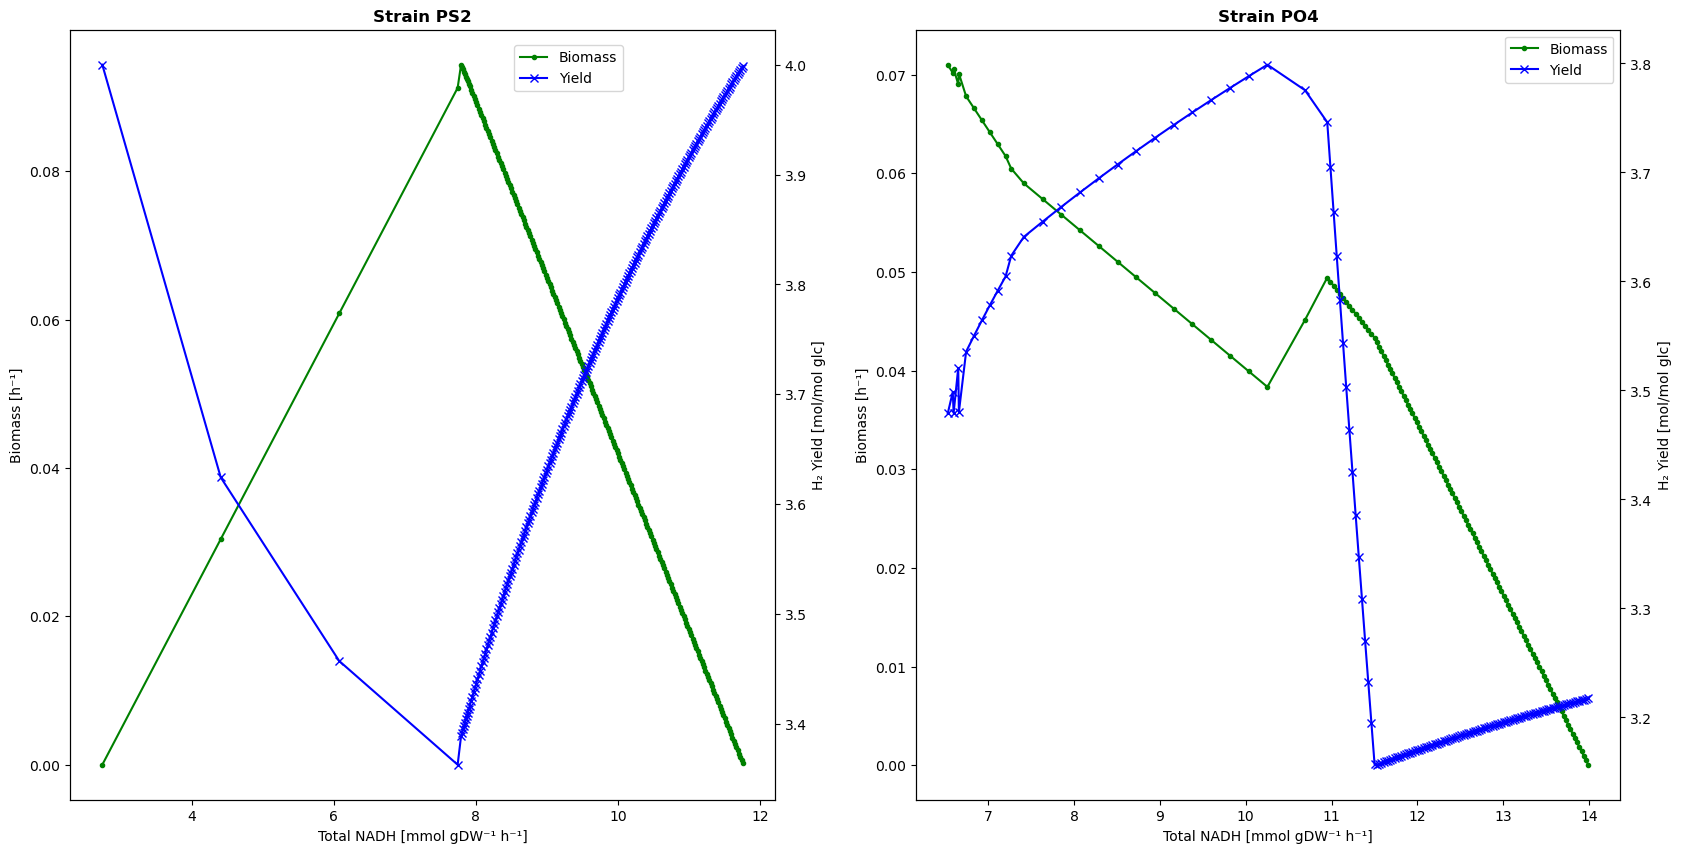

In [15]:
# Yield and biomass as a function of NADH concentration on the best-performing strains

fig = plt.figure(figsize=(20,10))
gs = GridSpec(1, 2,figure=fig)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

f.plot_yields(h2_2, df_PPC_LDH_KO, (0.63,0.92), 'Strain PS2', ax1)
f.plot_yields(h2_PO4, df_OGOR_PO4, 'upper right', 'Strain PO4', ax2)

fig.savefig('../Images/Line_Strain_Fluxes.png',dpi=1200)

In [17]:
df_h2_2 = pd.DataFrame(h2_2)
df_h2_PO4 = pd.DataFrame(h2_PO4)

#df_h2_2.to_csv('../Datasets/h2_2.csv',index=False)
#df_h2_PO4.to_csv('../Datasets/h2_PO4.csv',index=False)

# <b>End of Part 8!</b>